**Vorticity example** 
    
- from Kutz et al: Dynamic Mode Decomposition (book) (http://dmdbook.com/)

In [1]:
%run Streaming_DMD_functions.ipynb

import matplotlib.pyplot as plt
import scipy
import numpy as np
from matplotlib.patches import Polygon

In [2]:
mat = scipy.io.loadmat('CYLINDER_ALL.mat')
print(mat.keys())
u=mat['UALL']
v=mat['VALL']
vort=mat['VORTALL']


del mat
del u
del v

nx=199; ny=449

dict_keys(['__header__', '__version__', '__globals__', 'UALL', 'UEXTRA', 'VALL', 'VEXTRA', 'VORTALL', 'VORTEXTRA', 'm', 'n', 'nx', 'ny'])


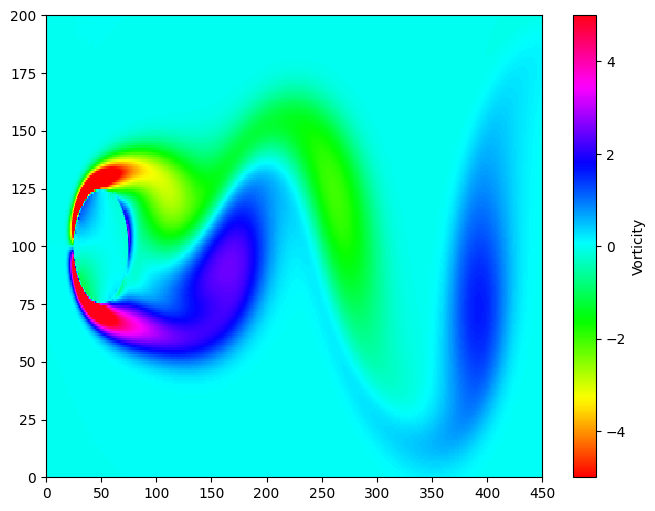

In [3]:
which=0

vort1=vort[:,which]

vort1 = vort1

fig, ax = plt.subplots(figsize=(8, 6))
y_os = np.linspace(0,200,200)
x_os = np.linspace(0,450,450)

c = ax.pcolormesh(x_os, y_os, vort1.reshape((-1,199)).T, cmap='hsv', vmin=-5, vmax=5)
fig.colorbar(c, ax=ax, label='Vorticity')



31
32
33


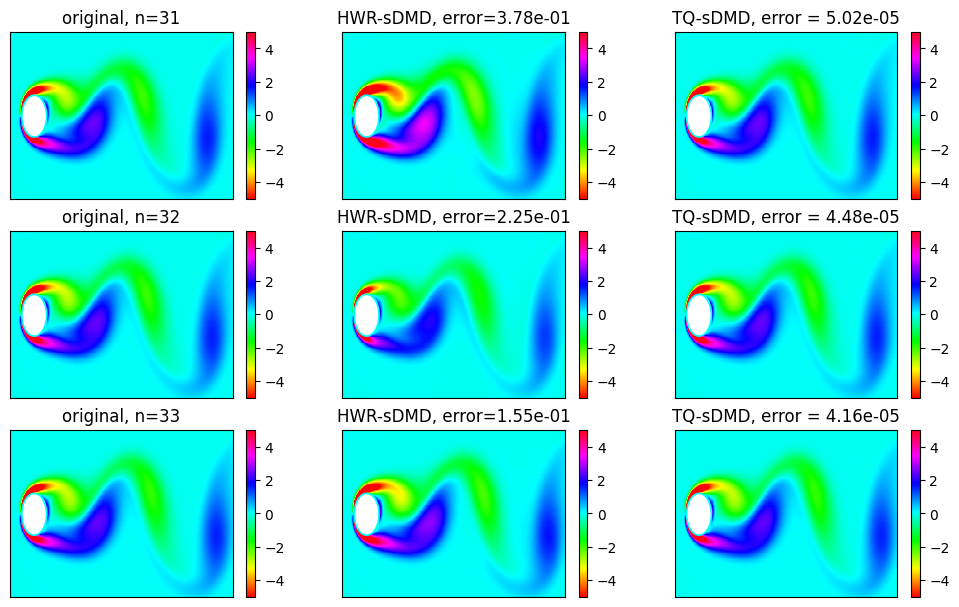

In [4]:
############################################################################################################
####        HWR-sDMD and TQ-sDMD comparison (fig 2 from paper)
############################################################################################################
m=vort.shape[1]

num_add=1
num_pred=1
poc=15
br_redaka=3

cmapp='hsv'

fig, axs = plt.subplots(br_redaka, 3, figsize=(10,6), squeeze=True)
plt.tight_layout(pad=0.2)

tol=1e-6
U_x, Sigma, _ = np.linalg.svd(vort[:,:poc-1],full_matrices=False) 
k=poc
for i in range(1,poc-1):
    if(Sigma[i]<=Sigma[0]*tol):
        k=i
        break
U_x = U_x[:, :k]

U_y, Sigma, _ = np.linalg.svd(vort[:,1:poc],full_matrices=False) 
k=poc
for i in range(1,poc-1):
    if(Sigma[i]<=Sigma[0]*tol):
        k=i
        break
U_y = U_y[:, :k]

X_tilda=U_x.T@vort[:,:poc-1]; Y_tilda=U_y.T@vort[:,1:poc]
Gyx = Y_tilda@X_tilda.T; Gx=X_tilda@X_tilda.T; Gy = Y_tilda@Y_tilda.T
Qxy = U_x.T@U_y

x=vort[:,poc-1:poc-1+num_add]

qqq, L_xh = np.linalg.qr(X_tilda.T)
YQh = Y_tilda@qqq
del(qqq)
L_xh = L_xh.T

U_x_lq = U_x
U_y_lq = U_y

br=0

theta = np.arange(1, 101) / 100 * 2 * np.pi
x_cil = 49 + 25 * np.sin(theta)
y_cil = 99 + 25 * np.cos(theta)


for i in range(poc, 151-num_add, num_add): 
    if(br==br_redaka):
        break
    times=[j for j in range(i+num_add, i+num_add+num_pred)]

    y=vort[:,i:(i+num_add)]
                                                                                    
    for k in range(num_add):
        U_x, U_y, Qxy, Gyx, Gx, Gy = Addxy_compress(U_x, U_y, Qxy, Gyx, Gx, Gy, x[:,k].reshape(-1,1), y[:,k].reshape(-1,1), tol1=1e-4, tol2=1e-1) 
        U_x_lq, U_y_lq, YQh, L_xh = AddxyTQ(U_x_lq, U_y_lq, YQh, L_xh, x[:,k].reshape(-1,1), y[:,k].reshape(-1,1), tol1=1e-4, tol2=1e-1)

    YQh=np.array(YQh, dtype="float32")
    L_xh = np.array(L_xh, dtype="float32")

    Gyx=np.array(Gyx, dtype="float32")
    Gx = np.array(Gx, dtype="float32")
    Gy = np.array(Gy, dtype="float32")

    Zh, Lh = DMD_compress_original(U_x, Qxy, Gyx, Gx)
    Zh_LQ, Lh_LQ = DMD_compress_original(U_x, U_x.T@U_y, YQh, L_xh)

    indices2 = np.where(abs(Lh) < 1e6)[0]
    indices3 = np.where(abs(Lh_LQ) < 1e6)[0]
    predicted_H = DMD_reconstruction(vort[:,:i+num_add], Zh, indices2, Lh, times)
    predicted_H_LQ = DMD_reconstruction(vort[:,:i+num_add], Zh_LQ, indices3, Lh_LQ, times)

    x = vort[:, i-1+num_add: i-1+num_add*2]
    if(i-poc<15):
        continue
    for j in range(num_pred):
    #original
        c1=axs[br,3*j].pcolormesh(x_os, y_os, vort[:,times[j]].reshape((-1,199)).T, cmap=cmapp, vmin=-5, vmax=5)
        print(times[j])
        plt.colorbar(c1, ax=axs[br,3*j], orientation='vertical')
        cylinder = Polygon(np.column_stack([x_cil, y_cil]), 
                   facecolor='white', 
                   edgecolor='cyan', 
                   linewidth=1.2,
                   zorder=10) 
        axs[br, 3*j].add_patch(cylinder)
        axs[br,3*j].set_xticks([]); axs[br,3*j].set_yticks([])
        axs[br, 3*j].set_title("original, n={}".format(times[j]))
    #HWR-sDMD
        c2=axs[br,3*j+1].pcolormesh(x_os, y_os, (predicted_H[:,j]).reshape((-1,199)).T, cmap=cmapp, vmin=-5, vmax=5)
        plt.colorbar(c2, ax=axs[br,3*j+1], orientation='vertical')
        res_hh = np.linalg.norm(predicted_H[:,j]-vort[:,times[j]])/np.linalg.norm(vort[:,times[j]])
        cylinder = Polygon(np.column_stack([x_cil, y_cil]), 
                   facecolor='white', 
                   edgecolor='cyan', 
                   linewidth=1.2,
                   zorder=10) 
        axs[br, 3*j+1].add_patch(cylinder)
        axs[br,3*j+1].set_xticks([]); axs[br,3*j+1].set_yticks([])
        axs[br,3*j+1].set_title("HWR-sDMD, error={}".format(np.format_float_scientific(res_hh, precision=2)))
    #TQ-sDMD
        c3=axs[br,3*j+2].pcolormesh(x_os, y_os, (predicted_H_LQ[:,j]).reshape((-1,199)).T, cmap=cmapp, vmin=-5, vmax=5)
        cylinder = Polygon(np.column_stack([x_cil, y_cil]), 
                   facecolor='white', 
                   edgecolor='cyan', 
                   linewidth=1.2,
                   zorder=10) 
        axs[br, 3*j+2].add_patch(cylinder)
        res_lq = np.linalg.norm(predicted_H_LQ[:,j]-vort[:,times[j]])/np.linalg.norm(vort[:,times[j]])
        plt.colorbar(c3, ax=axs[br,3*j+2], orientation='vertical')
        axs[br,3*j+2].set_title("TQ-sDMD, error = {}".format(np.format_float_scientific(res_lq, precision=2)))
        axs[br,3*j+2].set_xticks([]); axs[br,3*j+2].set_yticks([])
    br+=1

In [5]:
### HWR-sDMD - all relative error norms (32)

m=vort.shape[1]

all_res = []
num_add=1
num_pred=5
poc=20


tol=1e-6
U_x, Sigma, _ = np.linalg.svd(vort[:,:poc-1],full_matrices=False) 
k=poc
for i in range(1,poc-1):
    if(Sigma[i]<=Sigma[0]*tol):
        k=i
        break
U_x = U_x[:, :k]

U_y, Sigma, _ = np.linalg.svd(vort[:,1:poc],full_matrices=False) 
k=poc
for i in range(1,poc-1):
    if(Sigma[i]<=Sigma[0]*tol):
        k=i
        break
U_y = U_y[:, :k]

X_tilda=U_x.T@vort[:,:poc-1]; Y_tilda=U_y.T@vort[:,1:poc]
Gyx = Y_tilda@X_tilda.T; Gx=X_tilda@X_tilda.T; Gy = Y_tilda@Y_tilda.T
Qxy = U_x.T@U_y

x=vort[:,poc-1:poc-1+num_add]

br=0

for i in range(poc, 151 - num_pred, num_add): 

    times=[j for j in range(i+num_add, i+num_add+num_pred)]

    y=vort[:,i:(i+num_add)]
                                                                                    
    for k in range(num_add):
        U_x, U_y, Qxy, Gyx, Gx, Gy = Addxy_compress(U_x, U_y, Qxy, Gyx, Gx, Gy, x[:,k].reshape(-1,1), y[:,k].reshape(-1,1), tol1=1e-4, tol2=1e-1) 

    Gyx=np.array(Gyx, dtype="float32")
    Gx = np.array(Gx, dtype="float32")
    Gy = np.array(Gy, dtype="float32")

    Zh, Lh = DMD_compress_original(U_x, Qxy, Gyx, Gx)

    indices2 = np.where(abs(Lh) < 1e6)[0]
    predicted_H = DMD_reconstruction(vort[:,:i+num_add], Zh, indices2, Lh, times)

    x = vort[:, i-1+num_add: i-1+num_add*2]
    if(i == poc):
        res_H = np.linalg.norm(predicted_H-vort[:,times], axis=0).reshape(1,-1)/np.linalg.norm(vort[:,times], axis=0)
    else:
        res_H = np.vstack((res_H, np.linalg.norm(predicted_H-vort[:,times], axis=0).reshape(1,-1)/np.linalg.norm(vort[:,times], axis=0)))


In [6]:
### HWR-sDMD - all relative error norms (32) - using SOLVE in DMD

m=vort.shape[1]

all_res = []
num_add=1
num_pred=5
poc=20

tol=1e-6
U_x, Sigma, _ = np.linalg.svd(vort[:,:poc-1],full_matrices=False) 
k=poc
for i in range(1,poc-1):
    if(Sigma[i]<=Sigma[0]*tol):
        k=i
        break
U_x = U_x[:, :k]

U_y, Sigma, _ = np.linalg.svd(vort[:,1:poc],full_matrices=False) 
k=poc
for i in range(1,poc-1):
    if(Sigma[i]<=Sigma[0]*tol):
        k=i
        break
U_y = U_y[:, :k]

X_tilda=U_x.T@vort[:,:poc-1]; Y_tilda=U_y.T@vort[:,1:poc]
Gyx = Y_tilda@X_tilda.T; Gx=X_tilda@X_tilda.T; Gy = Y_tilda@Y_tilda.T
Qxy = U_x.T@U_y

x=vort[:,poc-1:poc-1+num_add]

br=0


for i in range(poc, 151 - num_pred, num_add): 

    times=[j for j in range(i+num_add, i+num_add+num_pred)]

    y=vort[:,i:(i+num_add)]
                                                                                    
    for k in range(num_add):
        U_x, U_y, Qxy, Gyx, Gx, Gy = Addxy_compress(U_x, U_y, Qxy, Gyx, Gx, Gy, x[:,k].reshape(-1,1), y[:,k].reshape(-1,1), tol1=1e-4, tol2=1e-1) 

    Gyx=np.array(Gyx, dtype="float32")
    Gx = np.array(Gx, dtype="float32")
    Gy = np.array(Gy, dtype="float32")

    Zh, Lh = DMD_compress(U_x, Qxy, Gyx, Gx)

    indices2 = np.where(abs(Lh) < 1e6)[0]
    predicted_H_solve = DMD_reconstruction(vort[:,:i+num_add], Zh, indices2, Lh, times)

    x = vort[:, i-1+num_add: i-1+num_add*2]
    if(i == poc):
        res_H_solve = np.linalg.norm(predicted_H_solve-vort[:,times], axis=0).reshape(1,-1)/np.linalg.norm(vort[:,times], axis=0)
    else:
        res_H_solve = np.vstack((res_H_solve, np.linalg.norm(predicted_H_solve-vort[:,times], axis=0).reshape(1,-1)/np.linalg.norm(vort[:,times], axis=0)))


C:\Users\elawi\AppData\Local\Temp\ipykernel_43364\2773524238.py:5: LinAlgWarning: Ill-conditioned matrix (rcond=4.27631e-09): result may not be accurate.
  L, W = np.linalg.eig(Qxy@(scipy.linalg.solve(Gx.T, Gyx.T, assume_a='pos').T))
C:\Users\elawi\AppData\Local\Temp\ipykernel_43364\2773524238.py:5: LinAlgWarning: Ill-conditioned matrix (rcond=3.2841e-09): result may not be accurate.
  L, W = np.linalg.eig(Qxy@(scipy.linalg.solve(Gx.T, Gyx.T, assume_a='pos').T))
C:\Users\elawi\AppData\Local\Temp\ipykernel_43364\2773524238.py:5: LinAlgWarning: Ill-conditioned matrix (rcond=2.55511e-09): result may not be accurate.
  L, W = np.linalg.eig(Qxy@(scipy.linalg.solve(Gx.T, Gyx.T, assume_a='pos').T))
C:\Users\elawi\AppData\Local\Temp\ipykernel_43364\2773524238.py:5: LinAlgWarning: Ill-conditioned matrix (rcond=2.17798e-09): result may not be accurate.
  L, W = np.linalg.eig(Qxy@(scipy.linalg.solve(Gx.T, Gyx.T, assume_a='pos').T))
C:\Users\elawi\AppData\Local\Temp\ipykernel_43364\2773524238.py:5

In [7]:
####        TQ-sDMD all error norms (32)
############################################################################################################

m=vort.shape[1]

num_add=1
num_pred=5
#poc = 130
poc=20

tol=1e-6
U_x, Sigma, _ = np.linalg.svd(vort[:,:poc-1],full_matrices=False) 
k=poc
for i in range(1,poc-1):
    if(Sigma[i]<=Sigma[0]*tol):
        k=i
        break
U_x = U_x[:, :k]

U_y, Sigma, _ = np.linalg.svd(vort[:,1:poc],full_matrices=False) 
k=poc
for i in range(1,poc-1):
    if(Sigma[i]<=Sigma[0]*tol):
        k=i
        break
U_y = U_y[:, :k]

X_tilda=U_x.T@vort[:,:poc-1]; Y_tilda=U_y.T@vort[:,1:poc]
qqq, L_xh = np.linalg.qr(X_tilda.T)
YQh = Y_tilda@qqq
del(qqq)
L_xh = L_xh.T

x=vort[:,poc-1:poc-1+num_add]

br=0

for i in range(poc, 151 - num_pred, num_add): 
    if(br==10):
        break
    times=[j for j in range(i+num_add, i+num_add+num_pred)]

    y=vort[:,i:(i+num_add)]
                                                                                    
    for k in range(num_add):
        U_x, U_y, YQh, L_xh = AddxyTQ(U_x, U_y, YQh, L_xh, x[:,k].reshape(-1,1), y[:,k].reshape(-1,1), tol1=1e-4, tol2=1e-1)

    YQh=np.array(YQh, dtype="float32")
    L_xh = np.array(L_xh, dtype="float32")

    Zh_LQ, Lh_LQ = DMD_compress_original(U_x, U_x.T@U_y, YQh, L_xh)

    indices3 = np.where(abs(Lh_LQ) < 1e6)[0]
    predicted_H_LQ = DMD_reconstruction(vort[:,:i+num_add], Zh_LQ, indices3, Lh_LQ, times)

    x = vort[:, i-1+num_add: i-1+num_add*2]
    if(i == poc):
        res_H_LQ = np.linalg.norm(predicted_H_LQ-vort[:,times], axis=0).reshape(1,-1)/np.linalg.norm(vort[:,times], axis=0)
    else:
        res_H_LQ = np.vstack((res_H_LQ, np.linalg.norm(predicted_H_LQ-vort[:,times], axis=0).reshape(1,-1)/np.linalg.norm(vort[:,times], axis=0)))

In [8]:
################### HWR-sDMD (64) - all error norms

m=vort.shape[1]

all_res = []
num_add=1
num_pred=5
poc=20


tol=1e-6
U_x, Sigma, _ = np.linalg.svd(vort[:,:poc-1],full_matrices=False) 
k=poc
for i in range(1,poc-1):
    if(Sigma[i]<=Sigma[0]*tol):
        k=i
        break
U_x = U_x[:, :k]

U_y, Sigma, _ = np.linalg.svd(vort[:,1:poc],full_matrices=False) 
k=poc
for i in range(1,poc-1):
    if(Sigma[i]<=Sigma[0]*tol):
        k=i
        break
U_y = U_y[:, :k]

X_tilda=U_x.T@vort[:,:poc-1]; Y_tilda=U_y.T@vort[:,1:poc]
Gyx = Y_tilda@X_tilda.T; Gx=X_tilda@X_tilda.T; Gy = Y_tilda@Y_tilda.T
Qxy = U_x.T@U_y

x=vort[:,poc-1:poc-1+num_add]

br=0

for i in range(poc, 151-num_pred, num_add): 

    times=[j for j in range(i+num_add, i+num_add+num_pred)]

    y=vort[:,i:(i+num_add)]
                                                                                    
    for k in range(num_add):
        U_x, U_y, Qxy, Gyx, Gx, Gy = Addxy_compress(U_x, U_y, Qxy, Gyx, Gx, Gy, x[:,k].reshape(-1,1), y[:,k].reshape(-1,1), tol1=1e-4, tol2=1e-1) 


    Zh, Lh = DMD_compress_original(U_x, Qxy, Gyx, Gx)

    indices2 = np.where(abs(Lh) < 1e6)[0]
    predicted_H = DMD_reconstruction(vort[:,:i+num_add], Zh, indices2, Lh, times)

    x = vort[:, i-1+num_add: i-1+num_add*2]
    if(i == poc):
        res_H_double = np.linalg.norm(predicted_H-vort[:,times], axis=0).reshape(1,-1)/np.linalg.norm(vort[:,times], axis=0)
    else:
        res_H_double = np.vstack((res_H_double, np.linalg.norm(predicted_H-vort[:,times], axis=0).reshape(1,-1)/np.linalg.norm(vort[:,times], axis=0)))

In [9]:
CB_color_cycle = ['#377eb8', '#ff7f00', '#4daf4a',
                  '#f781bf', '#a65628', '#984ea3',
                  '#999999', '#e41a1c', '#dede00']

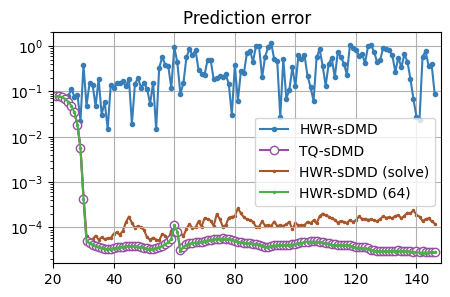

In [23]:
which = 0
plt.figure(figsize=(5,3))
plt.plot([[i] for i in range (21+which, 147+which)], res_H[:, which], label="HWR-sDMD", c=CB_color_cycle[0], ls="-", marker=".",)
plt.plot([[i] for i in range (21+which, 147+which)], res_H_LQ[:,which], label="TQ-sDMD", c=CB_color_cycle[5], ls="-", marker="o", markersize=6, markerfacecolor="white")
plt.plot([[i] for i in range (21+which, 147+which)], res_H_solve[:,which], label="HWR-sDMD (solve)", c=CB_color_cycle[4], ls="-", marker=".", markersize=3, zorder=0)
plt.plot([[i] for i in range (21+which, 147+which)], res_H_double[:,which], label="HWR-sDMD (64)", c=CB_color_cycle[2], ls="-", marker=".", markersize=3)
plt.grid()
plt.xlim(20+which,148+which)
plt.legend(loc=(0.52, 0.25))
plt.title("Prediction error")
#plt.title("Prediction error, ahead={}".format(which+1))
plt.yscale('log')

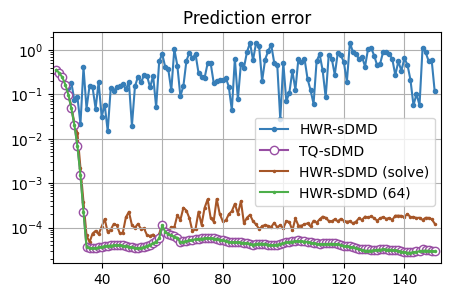

In [24]:
which = 4
plt.figure(figsize=(5,3))
plt.plot([[i] for i in range (21+which, 147+which)], res_H[:, which], label="HWR-sDMD", c=CB_color_cycle[0], ls="-", marker=".",)
plt.plot([[i] for i in range (21+which, 147+which)], res_H_LQ[:,which], label="TQ-sDMD", c=CB_color_cycle[5], ls="-", marker="o", markersize=6, markerfacecolor="white")
plt.plot([[i] for i in range (21+which, 147+which)], res_H_solve[:,which], label="HWR-sDMD (solve)", c=CB_color_cycle[4], ls="-", marker=".", markersize=3, zorder=0)
plt.plot([[i] for i in range (21+which, 147+which)], res_H_double[:,which], label="HWR-sDMD (64)", c=CB_color_cycle[2], ls="-", marker=".", markersize=3)
plt.grid()
plt.xlim(20+which,148+which)
plt.legend(loc=(0.52, 0.25))
plt.title("Prediction error")
#plt.title("Prediction error, ahead={}".format(which+1))
plt.yscale('log')

In [12]:
####       TQ-sDMD (64) - all error norms
############################################################################################################

m=vort.shape[1]

num_add=1
num_pred=5
#poc = 130
poc=20

tol=1e-6
U_x, Sigma, V_x = np.linalg.svd(vort[:,:poc-1],full_matrices=False) 
k=poc
for i in range(1,poc-1):
    if(Sigma[i]<=Sigma[0]*tol):
        k=i
        break
U_x = U_x[:, :k]

U_y, Sigma, _ = np.linalg.svd(vort[:,1:poc],full_matrices=False) 
k=poc
for i in range(1,poc-1):
    if(Sigma[i]<=Sigma[0]*tol):
        k=i
        break
U_y = U_y[:, :k]

X_tilda=U_x.T@vort[:,:poc-1]; 
Y_tilda=U_y.T@vort[:,1:poc]
qqq, L_xh = np.linalg.qr(X_tilda.T)
YQh = Y_tilda@qqq
del(qqq)
L_xh = L_xh.T

x=vort[:,poc-1:poc-1+num_add]

br=0

for i in range(poc, 151-num_pred, num_add): 
    if(br==10):
        break
    times=[j for j in range(i+num_add, i+num_add+num_pred)]

    y=vort[:,i:(i+num_add)]
                                                                                    
    for k in range(num_add):
        U_x, U_y, YQh, L_xh = AddxyTQ(U_x, U_y, YQh, L_xh, x[:,k].reshape(-1,1), y[:,k].reshape(-1,1), tol1=1e-4, tol2=1e-1)


    Zh_LQ, Lh_LQ = DMD_compress_original(U_x, U_x.T@U_y, YQh, L_xh)

    indices3 = np.where(abs(Lh_LQ) < 1e6)[0]
    predicted_H_LQ = DMD_reconstruction(vort[:,:i+num_add], Zh_LQ, indices3, Lh_LQ, times)

    x = vort[:, i-1+num_add: i-1+num_add*2]
    if(i == poc):
        res_H_LQ_double = np.linalg.norm(predicted_H_LQ-vort[:,times], axis=0).reshape(1,-1)/np.linalg.norm(vort[:,times], axis=0)
    else:
        res_H_LQ_double = np.vstack((res_H_LQ_double, np.linalg.norm(predicted_H_LQ-vort[:,times], axis=0).reshape(1,-1)/np.linalg.norm(vort[:,times], axis=0)))



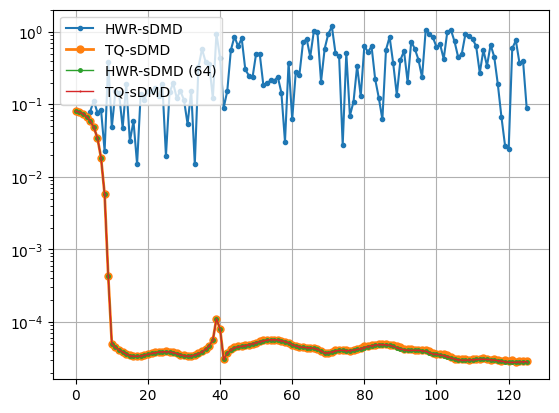

In [13]:
plt.plot(res_H[:, 0], label="HWR-sDMD", ls="-", marker=".")
plt.plot(res_H_LQ[:,0], label="TQ-sDMD", ls="-", marker=".", linewidth=2, markersize=10)
plt.plot(res_H_double[:, 0], label="HWR-sDMD (64)", ls="-", marker=".", linewidth=1, markersize=5)
plt.plot(res_H_LQ_double[:,0], label="TQ-sDMD", ls="-", marker=".", linewidth=1, markersize=1)
plt.grid()
plt.legend(loc=2)
plt.yscale('log')